In [1]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from IPython.display import display
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Enable and Confirm GPU Support
# XGboost must run a "dummy test" to confirm
try:
    xgb.train(
        {"device": "cuda"},
        xgb.DMatrix([[0]], label=[0]),
        num_boost_round=1
    )
    DEVICE = "cuda"
    print("GPU confirmed. XGBoost is using CUDA.")

except Exception as gpu_error:
    try:
        xgb.train(
            {"device": "cpu"},
            xgb.DMatrix([[0]], label=[0]),
            num_boost_round=1
        )
        DEVICE = "cpu"
        print(
            f"GPU support unavailable. [Reason: {gpu_error}]\n"
            f"Model has successfully defaulted to CPU usage instead."
        )

    except Exception as cpu_error:
        DEVICE = None
        print(
            f"GPU and CPU usage are both unavailable.\n"
            f"  GPU Reason: {gpu_error}\n"
            f"  CPU Reason: {cpu_error}\n\n"
            f"Troubleshooting suggestions:\n"
            f"  1. Verify XGBoost is installed correctly  : pip install xgboost\n"
            f"  2. Verify your CUDA drivers are up to date : https://developer.nvidia.com/cuda-downloads\n"
            f"  3. Confirm your Python environment is not corrupted\n"
            f"  4. Try reinstalling XGBoost                : pip install --force-reinstall xgboost"
        )

GPU confirmed. XGBoost is using CUDA.


In [3]:
# Define file path & Load TRAIN and VALIDATE Datasets
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TRAIN.txt')
df_val = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_VALIDATE.txt')

Mounted at /content/drive


In [4]:
# Zero-Variance Feature Scanner (Train & Validate)
def scan_zero_variance(df, name):
    zero_var_cols = [col for col in df.columns if df[col].nunique() <= 1]
    if zero_var_cols:
        print(f"[{name}] {len(zero_var_cols)} zero-variance column(s) found:")
        for col in zero_var_cols:
            unique_val = df[col].dropna().unique()
            val_display = unique_val[0] if len(unique_val) > 0 else "NaN (all missing)"
            print(f"    - '{col}'  →  constant value: {val_display}")
    else:
        print(f"[{name}] No zero-variance columns found.")
    return zero_var_cols

zv_train = scan_zero_variance(df,     "TRAIN")
zv_val   = scan_zero_variance(df_val, "VALIDATE")

# Combined: columns that are zero-variance in BOTH datasets
zv_both = list(set(zv_train) & set(zv_val))
if zv_both:
    print(f"\n[COMBINED] {len(zv_both)} column(s) are zero-variance in both datasets: {zv_both}")
else:
    print("\n[COMBINED] No columns are zero-variance in both datasets.")

[TRAIN] 2 zero-variance column(s) found:
    - 'num_outbound_cmds'  →  constant value: 0
    - 'is_host_login'  →  constant value: 0
[VALIDATE] 2 zero-variance column(s) found:
    - 'num_outbound_cmds'  →  constant value: 0
    - 'is_host_login'  →  constant value: 0

[COMBINED] 2 column(s) are zero-variance in both datasets: ['is_host_login', 'num_outbound_cmds']


In [5]:
# Drop Zero-Variance Columns (identified in previous cell)
cols_to_drop = list(set(zv_train) | set(zv_val))

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    df_val.drop(columns=cols_to_drop, inplace=True)
    print(f"Dropped {len(cols_to_drop)} zero-variance column(s): {cols_to_drop}")
    print(f"  Train shape   : {df.shape}")
    print(f"  Validate shape: {df_val.shape}")
else:
    print("No zero-variance columns detected")

Dropped 2 zero-variance column(s): ['is_host_login', 'num_outbound_cmds']
  Train shape   : (39928, 40)
  Validate shape: (12663, 40)


In [6]:
# XGBOOST CONFIGURATIONS
config = {

    #GLOBAL & GENERAL CONFIGURATIONS
    "verbosity"            : 1,                # 0 (silent), 1 (warning), 2 (info), 3 (debug)
    "booster"              : "gbtree",         # DEFAULT: gbtree --  Options: "gbtree" (Standard Gradient Boosting), "gblinear" (Linear Models), "dart" (Dropout Trees)
    "device"               : DEVICE,           # Options: "cuda", "cpu" - Specified in cell 2
    "validate_parameters"  : True,          # Use with Python. XGBoost validates input parameters and warns if any are unused or unrecognized.
    "disable_default_eval_metric" : False,    # XGBoost supports variety of "eval_metric" options with defaults and customizability.

    # TREE BOOSTER PARAMETERS
    "eta"                  : 0.05,              # DEFAULT: 0.3 - Alias for "learning_rate". Controls step size shrinkage to prevent overfitting.
    "gamma"                : 2,                # DEFAULT: 0 - Minimum loss reduction required to make a split. Higher values = more conservative models.
    "max_depth"            : 8,                # DEFAULT: 6 - Maximum depth of a tree. Increasing may capture more complex patterns BUT may overfit.
    "min_child_weight"     : 5,                # DEFAULT: 1 - [Options: 0,∞] Minimum sum of instance weight (hessian) needed in a child. Higher values prevent overfitting.
                                               # Relevant for U2R and R2L (Low # might cause overfitting)
    "max_delta_step"       : 1,                # DEFAULT: 0 - Maximum delta step allowed. 0 = no constraints. May help with logistic regressionin imbalanced datasets.
    "subsample"           : 0.8,                # DEFAULT: 1 - [Range: 0,1]Randomly subsample dataset prior to growing tree. May prevent overfitting. Occurs once per boosting iteration.
    "sampling_method"      : "uniform",        # DEFAULT: uniform - Options: "uniform" (Random sampling), "gradient_based" (Gradient-based sampling)
    "lambda"               : 3,                # DEFAULT: 1 - [Options: 0,∞] (Alias: reg_lambda) L2 regularization term on weights. Increase = more conservative models.
    "alpha"                : 1,                # DEFAULT: 0 - [Options: 0,∞] (Alias: reg_alpha) L1 regularization term on weights. Increase = more conservative models.
    "tree_method"         : "hist",            # DEFAULT: auto - Options: "auto" (same as "hist"), "exact" (Exact greedy algorithm), "approx" (Approximate algorithm using quantile sketching), "hist" (Histogram-based algorithm)
    "process_type"        : "default",         # DEFAULT: default - Options: "default" (Standard training), "update" (Continue training from existing model)
    "objective"            : "multi:softprob", # Many other options (see documentation), but "multi:softmax" is likely the most promising alternative.
    # "base_score" -- Automatically estimated by XGBoost for multi:softprob — no manual override needed
    "eval_metric" : ["mlogloss", "merror"], # Defaults to "mlogloss" for multi:softprob, but can be overridden with other options. See documentation.
    "seed" : 0, # RNG to ensure reproducibility of results across different runs/environments.
    "enable_categorical" : True, # Avoids using One-Hot Encoding and allows XGBoost to natively handle categorical features.
    "num_class"            : 5,  # Required for multiclass classification with "multi:softprob" objective. Specifies number of classes in the dataset.
    "n_estimators"         : 500,              # DEFAULT: 100 - Number of boosting rounds (trees).
    "early_stopping_rounds": 20,        # DEFAULT: None -- Early stopping if no imporvement (eval metric) for specified rounds.
    # Prototyping
    "prototyping"          : False,
    "prototyping_frac"     : 0.2,              # fraction of data to use when prototyping
    "prototyping_stratified": True,            # ensure all classes are represented
}

In [7]:
# TRAIN & VALIDATE Dataset: Encode datasets + separate Features and Targets
# Cast categorical feature columns to category dtype for XGBoost native handling
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    df[col]     = df[col].astype('category')
    df_val[col] = df_val[col].astype('category')

# Encode target class labels to integers (required by XGBoost)
le = LabelEncoder()
df['class']     = le.fit_transform(df['class'])
df_val['class'] = le.transform(df_val['class'])

# Print class encoding map
class_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class encoding map:")
for cls, idx in class_map.items():
    print(f"  {cls} → {idx}")

# Separate features and target
X_train = df.drop(columns=['class'])
y_train = df['class']

X_val   = df_val.drop(columns=['class'])
y_val   = df_val['class']

Class encoding map:
  DoS → 0
  Normal → 1
  Probe → 2
  R2L → 3
  U2R → 4


In [8]:
# Prototyping Configurations
if config["prototyping"]:
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train,
        train_size=config["prototyping_frac"],
        stratify=y_train if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    X_val, _, y_val, _ = train_test_split(
        X_val, y_val,
        train_size=config["prototyping_frac"],
        stratify=y_val if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    print(f"Prototyping mode: using {len(X_train)} train instances and {len(X_val)} val instances ({config['prototyping_frac']*100:.0f}% of each dataset)")
else:
    print(f"Full training mode: using {len(X_train)} train instances and {len(X_val)} val instances")

Full training mode: using 39928 train instances and 12663 val instances


In [9]:
model = xgb.XGBClassifier(
    verbosity          = config["verbosity"],
    booster            = config["booster"],
    device             = config["device"],
    validate_parameters= config["validate_parameters"],
    eta                = config["eta"],
    gamma              = config["gamma"],
    max_depth          = config["max_depth"],
    min_child_weight   = config["min_child_weight"],
    max_delta_step     = config["max_delta_step"],
    subsample          = config["subsample"],
    sampling_method    = config["sampling_method"],
    reg_lambda         = config["lambda"],
    reg_alpha          = config["alpha"],
    tree_method        = config["tree_method"],
    process_type       = config["process_type"],
    objective          = config["objective"],
    eval_metric        = config["eval_metric"],
    seed               = config["seed"],
    enable_categorical = config["enable_categorical"],
    num_class          = config["num_class"],
    n_estimators       = config["n_estimators"],
    early_stopping_rounds = config["early_stopping_rounds"],
)

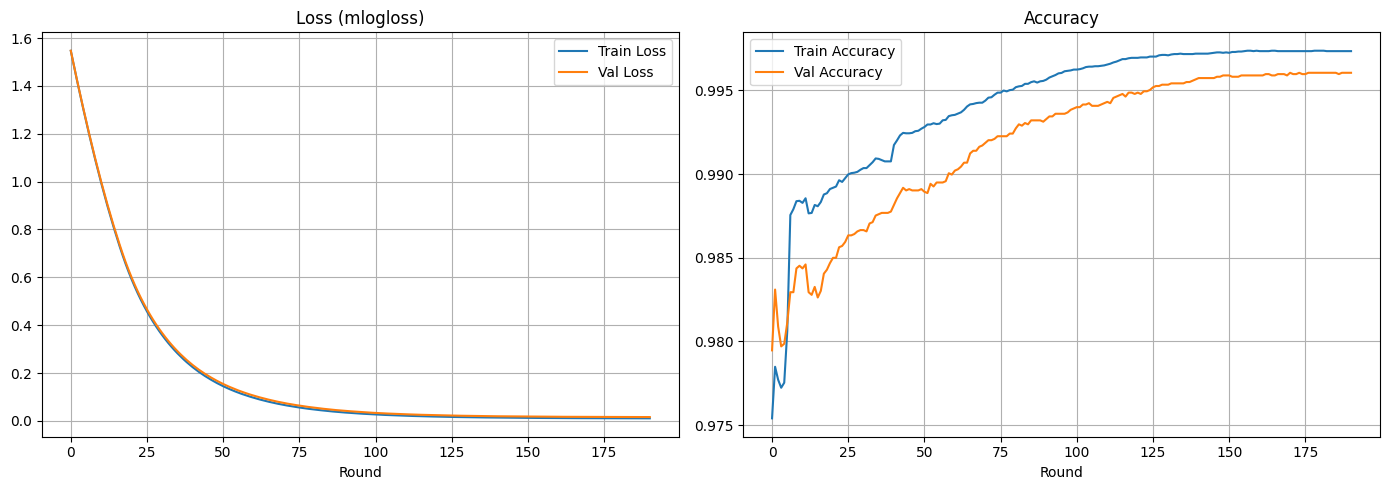

In [10]:
evals_result = {}

model.fit(
    X_train, y_train.to_numpy(),
    sample_weight=compute_sample_weight('balanced', y_train),
    eval_set=[(X_train, y_train.to_numpy()), (X_val, y_val.to_numpy())],
    verbose=False
)

# Plot after training
evals_result = model.evals_result()
train_loss = evals_result["validation_0"]["mlogloss"]
val_loss   = evals_result["validation_1"]["mlogloss"]
train_acc  = [1 - e for e in evals_result["validation_0"]["merror"]]
val_acc    = [1 - e for e in evals_result["validation_1"]["merror"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_loss, label="Train Loss")
ax1.plot(val_loss,   label="Val Loss")
ax1.set_title("Loss (mlogloss)")
ax1.set_xlabel("Round")
ax1.legend()
ax1.grid(True)

ax2.plot(train_acc, label="Train Accuracy")
ax2.plot(val_acc,   label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Round")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

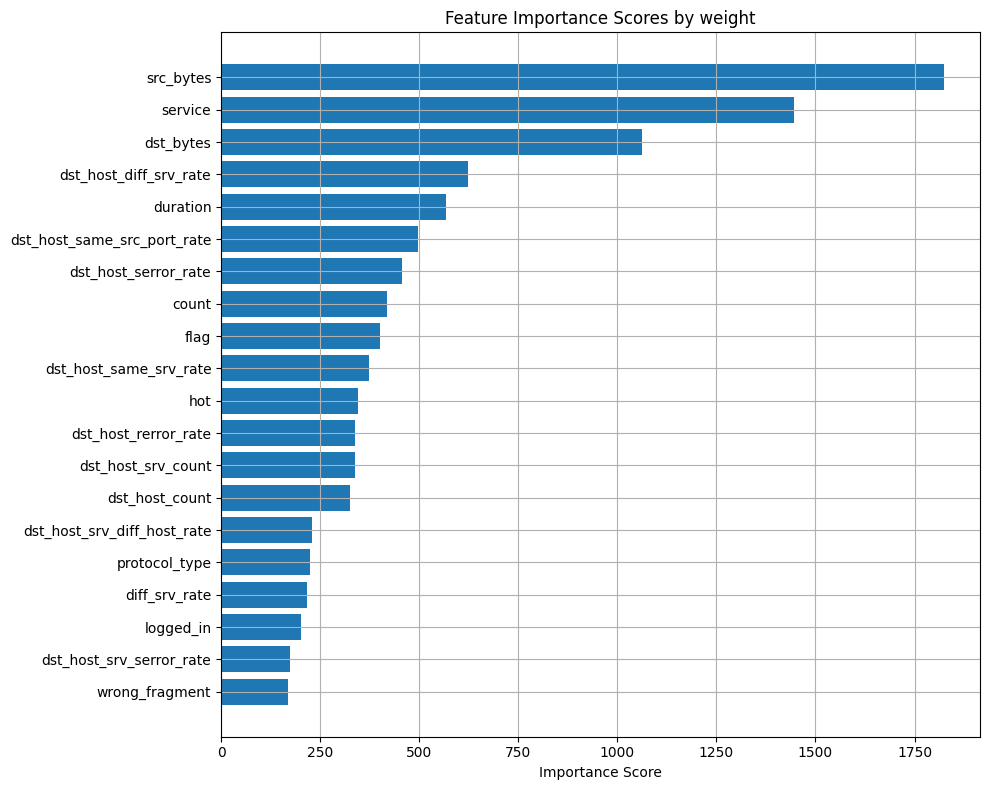


 Feature Importance Scores (weight):
                    feature  importance
                  src_bytes      1824.0
                    service      1445.0
                  dst_bytes      1061.0
     dst_host_diff_srv_rate       623.0
                   duration       567.0
dst_host_same_src_port_rate       497.0
       dst_host_serror_rate       456.0
                      count       418.0
                       flag       402.0
     dst_host_same_srv_rate       372.0
                        hot       345.0
       dst_host_rerror_rate       339.0
         dst_host_srv_count       337.0
             dst_host_count       326.0
dst_host_srv_diff_host_rate       230.0
              protocol_type       224.0
              diff_srv_rate       218.0
                  logged_in       201.0
   dst_host_srv_serror_rate       173.0
             wrong_fragment       169.0
                  srv_count       145.0
            num_compromised       137.0
              same_srv_rate       117.0
  

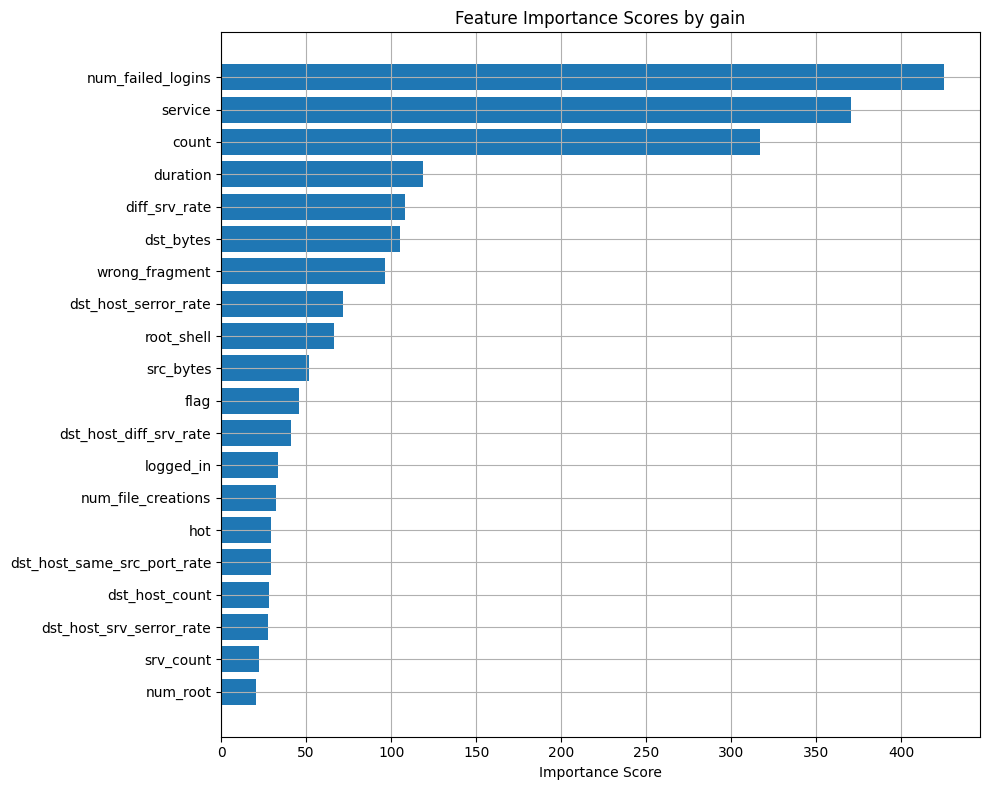


 Feature Importance Scores (gain):
                    feature  importance
          num_failed_logins  424.923401
                    service  370.546814
                      count  316.613861
                   duration  118.414879
              diff_srv_rate  108.063576
                  dst_bytes  105.194023
             wrong_fragment   96.348007
       dst_host_serror_rate   71.898689
                 root_shell   66.561302
                  src_bytes   51.400227
                       flag   45.622952
     dst_host_diff_srv_rate   41.329983
                  logged_in   33.235226
         num_file_creations   32.183582
                        hot   29.600100
dst_host_same_src_port_rate   29.368351
             dst_host_count   28.326998
   dst_host_srv_serror_rate   27.604803
                  srv_count   22.114380
                   num_root   20.501970
            num_compromised   19.059174
           num_access_files   18.560186
              protocol_type   17.534760
    

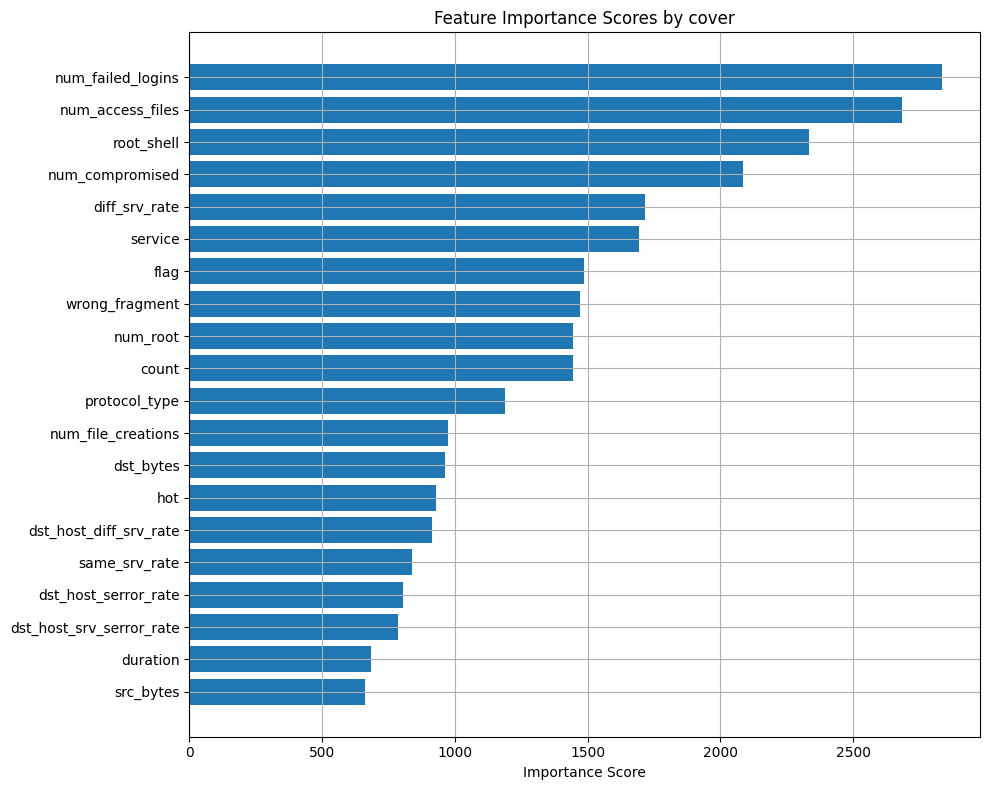


 Feature Importance Scores (cover):
                    feature  importance
          num_failed_logins 2836.023926
           num_access_files 2685.324707
                 root_shell 2334.256348
            num_compromised 2083.591553
              diff_srv_rate 1714.857056
                    service 1694.102539
                       flag 1484.713989
             wrong_fragment 1470.286011
                   num_root 1446.576050
                      count 1444.441284
              protocol_type 1189.304932
         num_file_creations  972.676880
                  dst_bytes  961.878357
                        hot  930.380859
     dst_host_diff_srv_rate  915.452454
              same_srv_rate  839.273560
       dst_host_serror_rate  805.257446
   dst_host_srv_serror_rate  787.100586
                   duration  683.233032
                  src_bytes  659.958923
                  logged_in  581.322144
       dst_host_rerror_rate  438.953857
         dst_host_srv_count  422.584442
   

In [11]:
# Feature Importance
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    scores = model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame({
        'feature': X_train.columns.tolist(),
        'importance': [scores.get(f, 0.0) for f in X_train.columns]
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top = importance_df.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance Scores by {imp_type}')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n Feature Importance Scores ({imp_type}):")
    print(importance_df.head(43).to_string(index=False))

In [12]:
# Load in Test Dataset, Encode it, and separate features and target
# Load test set
df_test = pd.read_csv('/content/drive/MyDrive/xg-ids/5class/datasets/5class_TEST.txt')

# Drop the same zero-variance columns removed from train/validate
if cols_to_drop:
    df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    print(f"Dropped {len(cols_to_drop)} zero-variance column(s) from test set.")

# Cast categorical feature columns to category dtype
for col in categorical_cols:
    df_test[col] = df_test[col].astype('category')

# Encode target using the same LabelEncoder fitted on train set
df_test['class'] = le.transform(df_test['class'])

# Separate features and target
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

print(f"Test set loaded: {len(df_test)} instances")

Dropped 2 zero-variance column(s) from test set.
Test set loaded: 22544 instances


Accuracy          : 0.8263
F1 (macro)        : 0.6436
F1 (weighted)     : 0.8137
Precision (weighted): 0.8301
Recall (weighted) : 0.8263

Per-class F1:
  DoS: 0.9030
  Normal: 0.8590
  Probe: 0.7740
  R2L: 0.4920
  U2R: 0.1901

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.85      0.90      7458
      Normal       0.77      0.97      0.86      9711
       Probe       0.78      0.77      0.77      2421
         R2L       0.75      0.37      0.49      2754
         U2R       0.40      0.12      0.19       200

    accuracy                           0.83     22544
   macro avg       0.73      0.62      0.64     22544
weighted avg       0.83      0.83      0.81     22544



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:58:04] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


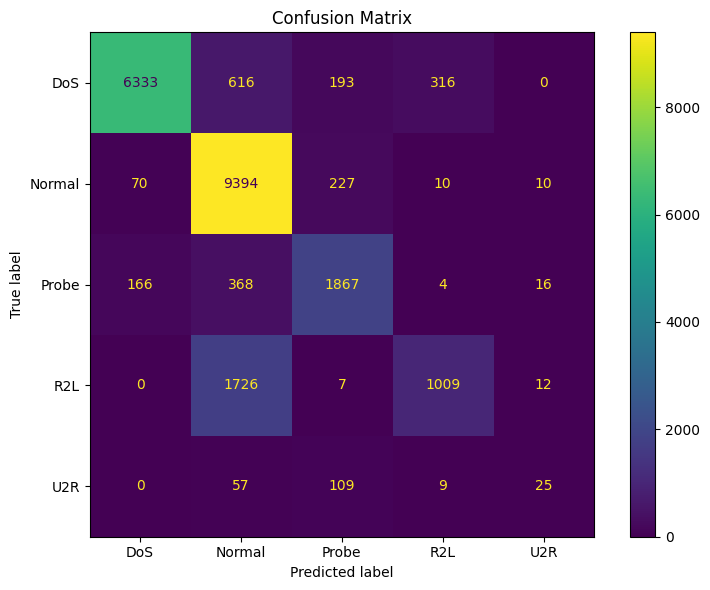

In [13]:
y_pred = model.predict(X_test)


accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy          : {accuracy:.4f}")
print(f"F1 (macro)        : {f1_macro:.4f}")
print(f"F1 (weighted)     : {f1_weighted:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted) : {recall:.4f}")

# F1-Score
f1_per_class = f1_score(y_test, y_pred, average=None)
print(f"\nPer-class F1:")
for cls, score in zip(le.classes_, f1_per_class):
    print(f"  {cls}: {score:.4f}")

# Classification
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()